In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from utils.model_definitions.text_automodel_wrapper import TextLayerwiseAutoModelWrapper, TextModelSpecifications

from utils.metrics.metric_calling import (
    calculate_and_save_layerwise_metrics,
    EvaluationMetricSpecifications
)
import utils.metrics.metric_functions as mf
from utils.dataloaders.text_dataloader import (
    get_dataloader,
)

In [2]:
from utils.model_definitions.text_automodel_wrapper import TextLayerwiseAutoModelWrapper, TextModelSpecifications

model_specs = TextModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = TextLayerwiseAutoModelWrapper(model_specs, device_map="auto")

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [3]:
dataloader = get_dataloader(
    model.tokenizer,
      "wikitext", 
      split="train", 
      num_samples=1000, 
      min_length=30, 
      batch_size=1,
      num_workers=0,
      filter_text_columns=True
)

Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Sun Dec 15 16:34:57 2024).


# Intrinsic Dimension

In [8]:
sample_ids = []
hs = []
for batch in tqdm.tqdm(dataloader):
    batch = model.prepare_inputs(batch)
    outputs = model(**batch)

    sample_hidden_states = [mf.normalize(layer_states.squeeze().detach()) for layer_states in outputs.hidden_states]
    sample_hidden_states = torch.stack(sample_hidden_states) # L x NUM_TOKENS x D
    hs.append(sample_hidden_states)

# remove everything but last token
hs = [hs[i][:, -1, :] for i in range(len(hs))]

# stack batch
hs = torch.stack(hs)

  1%|          | 3/388 [00:00<00:15, 25.08it/s]

100%|██████████| 388/388 [00:13<00:00, 28.00it/s]


In [11]:
hs.shape

torch.Size([25, 388, 1024])

In [13]:
from dadapy.data import Data as ID_DATA

ids = []
for layer in hs:
    layer = layer.detach().float().squeeze().cpu().numpy()
    data = ID_DATA(layer)
    id, id_error, id_distance = data.compute_id_2NN()
    ids.append(id)

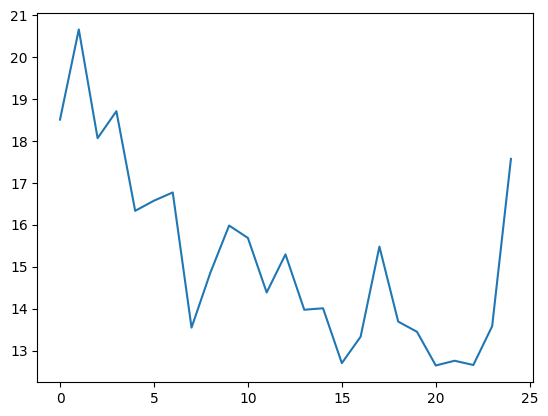

In [14]:
# plot the intrinsic dimension
# get the average intrinsic dimension
plt.plot(ids)
plt.show()


In [64]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="intrinsic_dimension")
dataloader_kwargs = {"dataset_name": "wikitext"}

results = calculate_and_save_layerwise_metrics(
    model, 
    dataloader, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs
)

Processing batches:   0%|          | 0/4324 [00:00<?, ?it/s]

Processing batches: 100%|██████████| 4324/4324 [17:58<00:00,  4.01it/s]


In [68]:
from utils.misc.results_saving import load_results
results = load_results(model_specs, evaluation_metric_specs, dataloader_kwargs)

In [70]:
print(results)

{'raw': array([0.  , 3.93, 5.48, 5.64, 6.31, 7.08, 7.41, 7.66, 7.9 , 8.3 , 8.09,
       7.98, 7.75, 7.75, 7.71, 7.54, 7.54, 7.39, 7.31, 7.26, 7.25, 7.18,
       7.17, 7.13, 7.29]), 'logN': array([0.  , 0.93, 1.27, 1.26, 1.4 , 1.56, 1.63, 1.67, 1.72, 1.8 , 1.76,
       1.73, 1.68, 1.68, 1.67, 1.63, 1.63, 1.6 , 1.58, 1.57, 1.57, 1.56,
       1.56, 1.55, 1.59])}


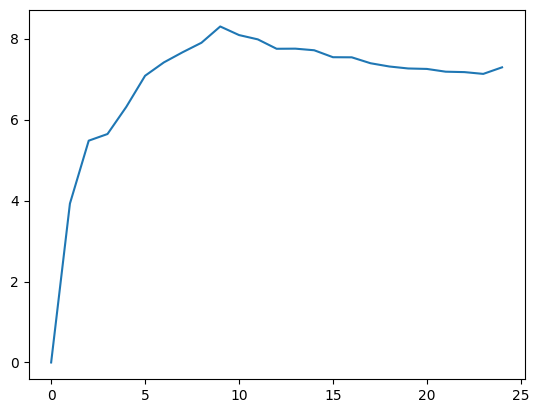

In [71]:
# plot the results
plt.plot(results['raw'])
plt.show()

# Fractal 1D

In [6]:
# load input string from dissertation.txt
with open('/home/AD/ofsk222/Research/exploration/information_plane/dissertation.txt', 'r') as file:
    input_string = file.read()

# tokenize the input string
tokenized_string = model.tokenizer(input_string, truncation=True, max_length=2048, return_tensors='pt')
tokenized_string = {k: v.to(model.device) for k, v in tokenized_string.items()}

tokenized_string['input_ids'].shape

torch.Size([1, 2048])

  0%|          | 0/2046 [00:00<?, ?it/s]

100%|██████████| 2046/2046 [02:20<00:00, 14.54it/s]


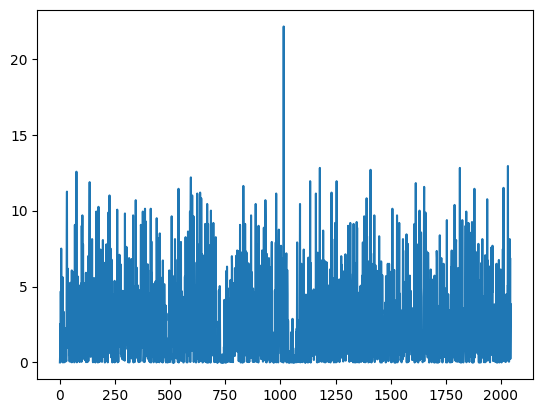

In [7]:
#for i in range(len(tokenized_string['input_ids'][0])):
correct_next_token_bits = []
start_idx = 2
for N in tqdm.tqdm(range(start_idx, len(tokenized_string['input_ids'][0]))):
    with torch.no_grad():
        trunc_string = {
            'input_ids': tokenized_string['input_ids'][0][:N].unsqueeze(0),
            'attention_mask': tokenized_string['attention_mask'][0][:N].unsqueeze(0)
        }
        correct_token = tokenized_string['input_ids'][0][N]

        outputs = model(**trunc_string)
        hidden_states = outputs.hidden_states

        next_token_logits = outputs.logits[:, -1, :]
        next_token_probs = torch.log_softmax(next_token_logits, dim=-1)
        correct_token_prob = next_token_probs[0, correct_token]
        correct_token_bits = -correct_token_prob

        correct_next_token_bits.append(correct_token_bits.item())

plt.plot(correct_next_token_bits)
plt.show()


In [9]:
bits_mean = np.mean(correct_next_token_bits)
bits_std = np.std(correct_next_token_bits)
bits_mean, bits_std


(2.614562672254277, 2.7791136548249087)

In [10]:
increment_process = []
integral_process = []

mu = np.mean(correct_next_token_bits)
sigma = np.std(correct_next_token_bits)

increment_process = (correct_next_token_bits - mu) / sigma
integral_process = np.cumsum(increment_process)
increment_process.shape, integral_process.shape


((2046,), (2046,))

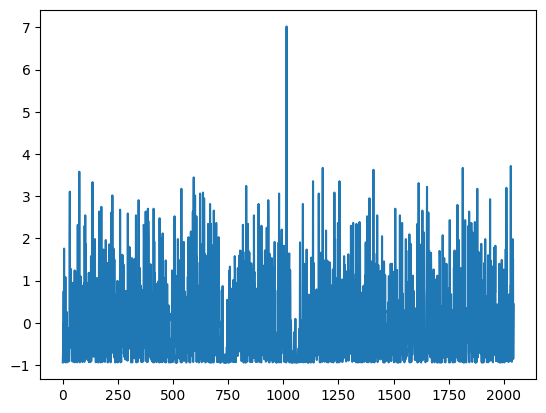

In [12]:
plt.plot(increment_process)
plt.show()

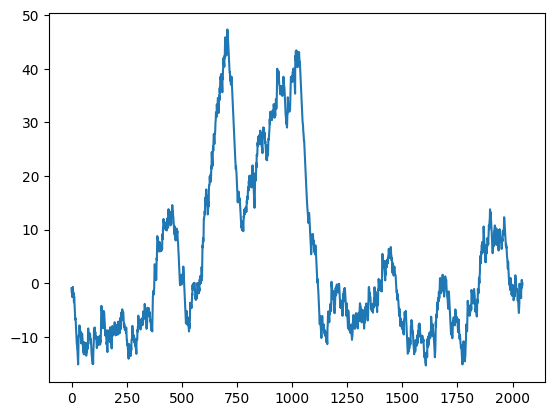

In [11]:
plt.plot(integral_process)
plt.show()

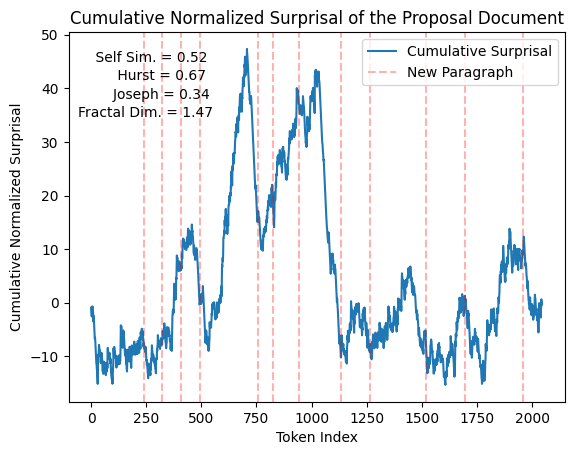

In [170]:
paragraphs = [242, 320, 409, 495, 755, 825, 944, 1135, 1264, 1518, 1697, 1957]

plt.plot(integral_process)
for paragraph in paragraphs:
    plt.axvline(paragraph, color='red', linestyle='--', alpha=0.3)

plt.xlabel("Token Index")
plt.ylabel("Cumulative Normalized Surprisal")
plt.title("Cumulative Normalized Surprisal of the Proposal Document")
plt.legend(["Cumulative Surprisal", "New Paragraph"], loc="upper right")

# put text in the top left which shows the self similarity exponent
plt.text(0.02, 0.95, f"    Self Sim. = 0.52", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)
plt.text(0.02, 0.90, f"         Hurst = 0.67", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)
plt.text(0.02, 0.85, f"        Joseph = 0.34", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)
plt.text(0.02, 0.80, f"Fractal Dim. = 1.47", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)

plt.savefig("2048_cumulative_normalized_surprisal.pdf")
plt.show()

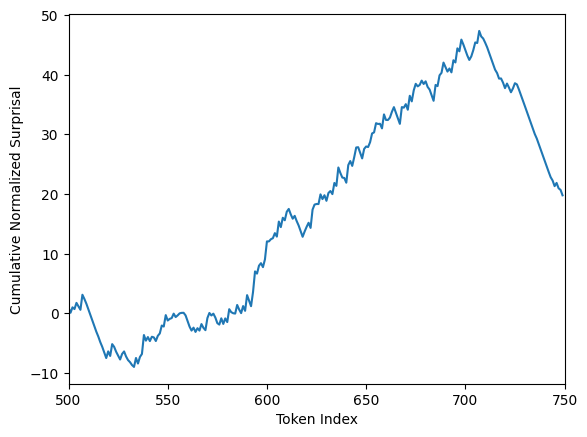

In [49]:
# plot the values from 500 to 750
plt.plot([0]*500 + list(integral_process[500:750]))

# make the x axis start at 500, end at 750
plt.xlim(500, 750)
plt.xlabel("Token Index")
plt.ylabel("Cumulative Normalized Surprisal")

plt.savefig("500_750_cumulative_normalized_surprisal.pdf")
plt.show()

In [117]:
import sklearn.linear_model

def power_law_fit(x, y):
  """Fit a power law to the data (x, y)."""
  ones_logx = np.stack([np.ones_like(x), np.log(x)], axis=1)
  logy = np.log(y)
  print(logy)
  clf = sklearn.linear_model.LinearRegression(
      fit_intercept=False).fit(ones_logx, logy)
  return clf.coef_[0], clf.coef_[1]  # coeff, exponent


def get_self_sim_exponent(X,
                          scales=[25, 50, 75, 100, 200, 250],
                          samples_per_doc=1000,
                          eps=5e-1):
  """Calculate the self-similarity exponent.

  Args:
    X: integral process, 1D or 2D array.
    scales: granuality levels. Choose this carefully.
      If it is too large, you will have very few measurements.
      If it is too small, your estimate of the power law relation will be
      unreliable.
    samples_per_doc: number of samples per document. Ideally, this should be
      small and the number of documents should be large.
    eps: used for calculating peak probability scores. Choose this carefully.
      If eps is too small, probability estimates will be unreliable.
      If eps is too large, it doesn't reflect peak probabiliy at the origin.

  Returns:
    S: self-similarity exponent.
    p0: peak probability estimates.
  """
  if X.ndim == 1:
    X = X.reshape((1, -1))
  elif X.ndim > 2:
    raise ValueError('X.ndim must be 1 or 2.')

  p0 = []
  for n in scales:
    all = []
    for i in (range(len(X))):
      for idx in range(samples_per_doc):
        print(idx)
        offset = np.random.randint(0, len(X[i]) - n)
        all.append(X[i][offset + n] - X[i][offset])
    all = np.array(all)
    p0.append(np.mean(np.abs(all) < eps))

  # estimate Holder exponent
  print(p0)
  return -power_law_fit(scales, p0)[1], p0
     

In [119]:
np.random.seed(2024)
self_sim_exponent = get_self_sim_exponent(integral_process, eps=4e-1)


print(self_sim_exponent)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [129]:
def get_hurst_exponent(x,
                       scales=[25, 50, 75, 100, 200, 250],
                       samples_per_doc=1000):
  """Calculate the Hurst exponent.

  Args:
    x: increment process, 1D or 2D array.
    scales: granuality levels. Choose this carefully.
      If it is too large, you will have very few measurements.
      If it is too small, your estimate of the power law relation will be
      unreliable.
    samples_per_doc: number of samples per document. Ideally, this should be
      small and the number of documents should be large.

  Returns:
    H: Hurst exponent.
    sr: rescaled range estimates.
  """
  if x.ndim == 1:
    x = x.reshape((1, -1))
  elif x.ndim > 2:
    raise ValueError('x.ndim must be 1 or 2.')

  # calculate the rescaled range
  sr = []
  for n in scales:
    som = 0
    count = 0
    for i in range(len(x)):  # to get a reliable etimate, many documents are needed
      for _ in range(samples_per_doc):
        offset = np.random.randint(0, len(x[i]) - n)
        y = x[i, offset: n + offset]
        y = y - np.mean(y)
        Y = np.cumsum(y)
        R = max(Y) - min(Y)
        S = np.std(y)
        som += R / S
        count += 1
    sr.append(som / count)

  # estimate Hurst exponent
  return power_law_fit(scales, sr)[1], sr

In [133]:
np.random.seed(2024)
hurst_exponent = get_hurst_exponent(increment_process)
print(hurst_exponent)

[1.68 2.1  2.33 2.5  3.05 3.22]
(0.6703712818227369, [5.378215129788233, 8.15985416915549, 10.22767820550738, 12.159157418036855, 21.044041278387294, 25.092702218826187])


In [150]:
def get_joseph_exponent(seq,
                        scales=[25, 50, 75, 100, 200, 250],
                        samples_per_doc=1000):
  """Calculate the Joseph exponent.

  Args:
    x: increment process, 1D or 2D array.
    scales: granuality levels. Choose this carefully.
      If it is too large, you will have very few measurements.
      If it is too small, your estimate of the power law relation will be
      unreliable.
    samples_per_doc: number of samples per document. Ideally, this should be
      small and the number of documents should be large.

  Returns:
    J: Joseph exponent.
    sigmas: standard deviations estimate.
  """
  if seq.ndim == 1:
    seq = seq.reshape((1, -1))
  elif seq.ndim > 2:
    raise ValueError('x.ndim must be 1 or 2.')

  sigmas = []
  v = []
  for n in scales:
    for i in range(len(seq)):
      for _ in range(samples_per_doc):
        offset = np.random.randint(0, len(seq[i]) - n)
        v.extend([seq[i][offset + n] - seq[i][offset]])
    sigmas.append(np.std(v))

  # estimate Joseph exponent
  return power_law_fit(scales, sigmas)[1], sigmas

In [152]:
get_joseph_exponent(integral_process)

[1.83 2.14 2.3  2.45 2.57 2.64]


(0.3455540877996764,
 [6.238428836882792,
  8.466776106189052,
  9.968455298846271,
  11.62772298454625,
  13.123741720113387,
  13.99730540711005])

In [ ]:
# compute the fractal dimension
fractal_dimension = 1 - self_sim_exponent[0]
print(fractal_dimension)

In [161]:
def fractal_dimension(data, 
                      epsilons = [25, 50, 75, 100, 200, 250]):
    """
    Computes the fractal dimension of a 1D list using the box-counting method.

    Parameters:
        data (list or np.array): The input 1D list or array.
        epsilons (list or np.array): List of box sizes to evaluate.

    Returns:
        fractal_dim (float): The computed fractal dimension.
    """
    data = np.array(data)
    box_counts = []

    for epsilon in epsilons:
        # Find the number of boxes that contain at least one point
        bins = np.arange(data.min(), data.max() + epsilon, epsilon)
        digitized = np.digitize(data, bins)
        box_count = len(np.unique(digitized))
        box_counts.append(box_count)

    # Convert to log-log space
    log_epsilons = np.log(1 / np.array(epsilons))
    log_box_counts = np.log(box_counts)

    # Fit a line to find the slope, which is the fractal dimension
    coeffs = np.polyfit(log_epsilons, log_box_counts, 1)
    fractal_dim = coeffs[0]

    # Plot for visualization
    plt.figure(figsize=(8, 6))
    plt.plot(log_epsilons, log_box_counts, 'o-', label="Data")
    plt.plot(log_epsilons, np.polyval(coeffs, log_epsilons), 'r--', label="Fit")
    plt.xlabel("log(1/epsilon)")
    plt.ylabel("log(box count)")
    plt.legend()
    plt.title("Fractal Dimension Estimation")
    plt.show()

    return fractal_dim

In [163]:
fractal_dim = 2 - self_sim_exponent[0]
print(fractal_dim)

1.47817358922129


# Try different Sizes of model

In [5]:
from utils.model_definitions.text_automodel_wrapper import TextLayerwiseAutoModelWrapper, TextModelSpecifications

sizes = ["14m", "70m", "160m", "410m", "1b", "1.4b"]
#sizes = ["14m", "70m"]
size_to_correct_next_token_bits = {}

for size in sizes:
    model_specs = TextModelSpecifications(
        model_family="Pythia",
        model_size=size,
        revision="main"
        )
    model = TextLayerwiseAutoModelWrapper(model_specs, device_map="auto")

    # load input string from dissertation.txt
    with open('/home/AD/ofsk222/Research/exploration/information_plane/dissertation.txt', 'r') as file:
        input_string = file.read()

    # tokenize the input string
    tokenized_string = model.tokenizer(input_string, truncation=True, max_length=2048, return_tensors='pt')
    tokenized_string = {k: v.to(model.device) for k, v in tokenized_string.items()}

    tokenized_string['input_ids'].shape

    correct_next_token_bits = []
    start_idx = 2
    for N in tqdm.tqdm(range(start_idx, len(tokenized_string['input_ids'][0]))):
        trunc_string = {
            'input_ids': tokenized_string['input_ids'][0][:N].unsqueeze(0),
            'attention_mask': tokenized_string['attention_mask'][0][:N].unsqueeze(0)
        }
        correct_token = tokenized_string['input_ids'][0][N]

        outputs = model(**trunc_string)
        hidden_states = outputs.hidden_states

        next_token_logits = outputs.logits[:, -1, :]
        next_token_probs = torch.log_softmax(next_token_logits, dim=-1)
        correct_token_prob = next_token_probs[0, correct_token]
        correct_token_bits = -correct_token_prob

        correct_next_token_bits.append(correct_token_bits.item())

    size_to_correct_next_token_bits[size] = correct_next_token_bits
    del model

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 2046/2046 [00:20<00:00, 101.14it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
100%|██████████| 2046/2046 [00:25<00:00, 80.51it/s]
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tok

In [6]:
size_to_increment_process = {}
size_to_integral_process = {}

for size in sizes:
    correct_next_token_bits = size_to_correct_next_token_bits[size]

    mu = np.mean(correct_next_token_bits)
    sigma = np.std(correct_next_token_bits)

    increment_process = (correct_next_token_bits - mu) / sigma
    integral_process = np.cumsum(increment_process)

    size_to_increment_process[size] = increment_process
    size_to_integral_process[size] = integral_process

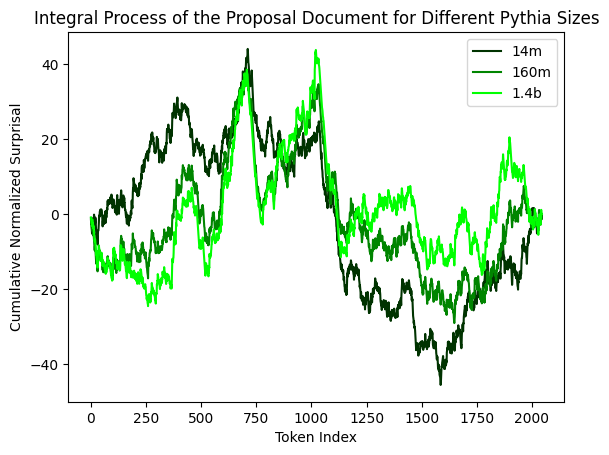

In [14]:
# plot the results
# Create color map from light to dark green based on index
for i, size in enumerate(sizes):
    # Normalize index to [0,1] range for color intensity 
    color_intensity = i / (len(sizes) - 1)
    color = (0, 0.2 + 0.8 * color_intensity, 0)  # Varying shades of green
    if size in ["14m", "160m", "1.4b"]:
        plt.plot(size_to_integral_process[size], color=color, label=f'{size}')
plt.legend()

plt.title("Integral Process of the Proposal Document for Different Pythia Sizes")
plt.xlabel("Token Index")
plt.ylabel("Cumulative Normalized Surprisal")
plt.show()
